# Pivot dataframe: long -> wide tables
## Example 1: patent data

Here I am using a data from my research [linked here](https://www.nature.com/articles/s41599-025-06038-6).

The data contains the following columns:
- filing_year: the years of patent filing, 1976-2021
- gender_collab_type: a categorical variable indicating the gender composition of the patent's inventor team. There are three possible values: only_females, only_males, and gender_collab.
- reliance_on_public_funding: a categorical variable whether the patent relies on public funding, such as federal research grants. There are three possible values: Indirect, Direct, and No_support.
- patent_count: the number of patent filed in that year that belong to the two categories specified in `gender_collab_type` and `reliance_on_public_funding`.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

use_cols = ['filing_year', 'gender_collab_type',
       'gov_reliance_type_three_type', 'patent_count']
df=pd.read_csv("../07-Data_visualization/data/time_series_three_gov_support_by_gender_collab_type_20250624.csv", usecols=use_cols,
               dtype={'filing_year': int, "patent_count": int}).rename(columns={"gov_reliance_type_three_type":"reliance_on_public_funding"})

df

In [ ]:
df.info()

### Basic Pivot Table (Single Dimension)

Goal: Total patent counts by gender collaboration type
- `index`: rows
- `values`: what we aggregate
- `aggfunc="sum"`: total patents

In [4]:
pivot_1 = pd.pivot_table(
    data=df,
    values="patent_count",
    index="gender_collab_type",
    aggfunc="sum"
)

pivot_1

,patent_count
gender_collab_type,
gender_collab,551785
only_females,99542
only_males,3045544


Above cell is actually equivalent to `df.groupby("gender_collab_type")['patent_count'].sum()`.

### Two-Dimensional Pivot
Compare gender collaboration × government reliance

- Adds columns dimension
- Creates a matrix (like contingency table but with values)


In [6]:
pivot_2 = pd.pivot_table(
    data=df,
    values="patent_count",
    index="gender_collab_type",
    columns="reliance_on_public_funding",
    aggfunc="sum"
)

pivot_2

reliance_on_public_funding,Direct,Indirect,No_support
gender_collab_type,,,
gender_collab,27344,85586,438855
only_females,2867,10906,85769
only_males,96254,431921,2517369


Above cell is equivalent to `pd.crosstab(df['gender_collab_type'], df['reliance_on_public_funding'], values=df['patent_count'], aggfunc='sum')`

### Add Time Dimension (Multi-Index)

In [9]:
pivot_3 = pd.pivot_table(
    df,
    values="patent_count",
    index=["filing_year", "gender_collab_type"],
    columns="reliance_on_public_funding",
    aggfunc="sum"
).reset_index()

pivot_3

reliance_on_public_funding,filing_year,gender_collab_type,Direct,Indirect,No_support
0,1976,gender_collab,76.0,104.0,1224.0
1,1976,only_females,18.0,56.0,784.0
2,1976,only_males,1772.0,3553.0,44226.0
3,1977,gender_collab,88.0,75.0,1045.0
4,1977,only_females,18.0,57.0,691.0
...,...,...,...,...,...
133,2020,only_females,NaN,NaN,3392.0
134,2020,only_males,NaN,NaN,89022.0
135,2021,gender_collab,NaN,NaN,21398.0
136,2021,only_females,NaN,NaN,2794.0


Or if we are only interested in the number of patents filed by teams of different gender composition regardless of their funding situation:

In [10]:
pivot_3_alt = pd.pivot_table(
    df,
    values="patent_count",
    index="filing_year",
    columns="gender_collab_type",
    aggfunc="sum"
)

pivot_3_alt.head()

gender_collab_type,gender_collab,only_females,only_males
filing_year,,,
1976,1404,858,49551
1977,1208,766,40198
1978,1100,765,37661
1979,1167,777,36965
1980,1272,731,36857


Or only interested in the reliance on public funding, regardless of their gender composition

In [ ]:
pivot_3_alt_1 = pd.pivot_table(
    df,
    values="patent_count",
    index="filing_year",
    columns="reliance_on_public_funding",
    aggfunc="sum"
)

print(pivot_3_alt_1.head())

### Multiple columns to pivot

Goal: if we wanted to pivot the table to a wide table with nine columns, representing the nine groups based on the two categorical variables:

In [ ]:
pivot_wide = pd.pivot_table(
    data=df,
    values="patent_count",
    index="filing_year",
    columns=["gender_collab_type","reliance_on_public_funding"],
    aggfunc="sum",
    fill_value=0
)

pivot_wide

### Multiple Aggregations
Goal: Compute both sum and mean


In [ ]:
pivot_4 = pd.pivot_table(
    df,
    values="patent_count",
    index="gender_collab_type",
    columns="reliance_on_public_funding",
    aggfunc=["sum", "mean"],
    margins=True, # try change it to True and False
)

pivot_4

### Normalize (Share within Group)
Goal: Convert counts into proportions

In [ ]:
pivot = pd.pivot_table(
    df,
    values="patent_count",
    index="gender_collab_type",
    columns="reliance_on_public_funding",
    aggfunc="sum",
    margins=False, # if set it as True, it will take half of the value (proportion)
)

pivot

In [ ]:
# Normalize row-wise
pivot_norm_row_wise = pivot.div(pivot.sum(axis=1), axis=0)

# Normalize col-wise
pivot_norm_col_wise = pivot.div(pivot.sum(axis=0), axis=1)

print("Pivot table (normalized row-wise):")
print(pivot_norm_row_wise)


print("\nPivot table (normalized column-wise):")
print(pivot_norm_col_wise)

## Example 2: Stony Brook temperature

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../07-Data_visualization/data/stony_brook_daily_temperature_2025.csv")

# Convert Celsius → Fahrenheit
df["temp_F"] = df["average_temperature"] * 9/5 + 32

df

,month,day,average_temperature,temp_F
0,1,1,7.5,45.50
1,1,2,3.3,37.94
2,1,3,0.6,33.08
3,1,4,-1.5,29.30
4,1,5,-2.3,27.86
...,...,...,...,...
360,12,27,-3.3,26.06
361,12,28,-2.8,26.96
362,12,29,5.8,42.44
363,12,30,-1.2,29.84


In [12]:
df.columns


Index(['month', 'day', 'average_temperature', 'temp_F'], dtype='object')

#### Average Temperature by Month

In [13]:
pivot_1 = pd.pivot_table(
    df,
    values="temp_F",
    index="month",
    aggfunc="mean"
)

pivot_1

,temp_F
month,
1,29.886452
2,32.559286
3,43.479355
4,51.092000
5,59.632903
6,70.028000
7,75.908387
8,70.601290
9,67.292000


#### Day × Month Matrix (Temperature Table)

In [14]:
pivot_2 = pd.pivot_table(
    df,
    values="temp_F",
    index="day",
    columns="month",
    aggfunc="mean"
)

pivot_2

month,1,2,3,4,5,6,7,8,9,10,11,12
day,,,,,,,,,,,,
1,45.50,35.06,43.88,47.48,59.18,54.86,76.82,64.22,66.20,60.80,51.08,39.02
2,37.94,21.20,24.08,39.56,63.14,59.54,73.58,69.08,66.56,57.74,49.28,37.58
3,33.08,37.04,23.72,49.64,65.66,65.48,75.56,71.42,66.02,60.08,54.50,34.34
4,29.30,38.84,36.86,62.78,62.42,68.54,69.98,73.76,67.82,65.84,51.44,35.60
5,27.86,27.14,48.02,49.46,59.72,73.58,73.94,74.66,71.60,72.14,54.68,24.08
6,27.86,31.28,48.56,43.70,59.90,73.40,75.38,70.52,72.68,68.54,50.54,36.68
7,22.64,36.50,36.50,42.26,61.88,69.80,76.10,70.52,61.52,67.82,47.84,37.94
8,23.90,28.76,38.66,38.30,66.20,65.30,79.34,70.16,62.78,65.48,57.38,29.84
9,24.62,29.66,37.22,34.52,57.56,60.08,77.36,70.70,64.22,54.68,56.84,23.90


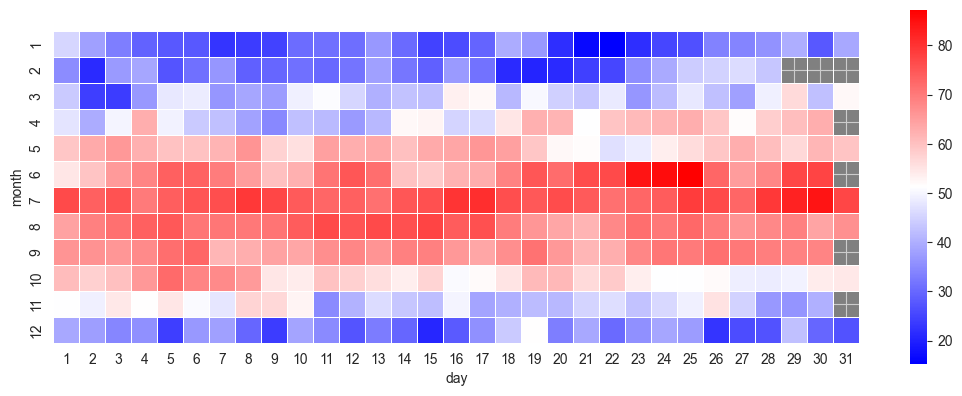

In [15]:
# we can create a heatmap using this matrix

fig, ax = plt.subplots(1, 1, figsize=(13, 4.6))

sns.heatmap(pivot_2.T, ax=ax, cmap="bwr", linewidths=.4, square=True,
            annot=False)

ax.set_facecolor('grey')

#### Max Temperature by Month

In [18]:
pivot_3 = pd.pivot_table(
    df,
    values="temp_F",
    index="month",
    aggfunc="median"
)

pivot_3

,temp_F
month,
1,29.48
2,31.55
3,43.34
4,51.35
5,60.08
6,70.25
7,75.56
8,70.52
9,67.55


#### Add “Temperature Category” and Pivot

In [ ]:
# Create temperature categories
df["temp_category"] = pd.cut(
    df["temp_F"],
    bins=[0, 40, 60, 80, 100],
    labels=["Cold", "Mild", "Warm", "Hot"]
)

pivot_5 = pd.pivot_table(
    df,
    values="temp_F",
    index="month",
    columns="temp_category",
    aggfunc="count",
    fill_value=0,
    observed=True
)

print(pivot_5)